# Workforce Risk Intelligence - Visual Analytics

This notebook contains production-ready visualizations for the Workforce Risk Intelligence module. Each chart includes a brief business objective followed by the visualization code.


## Chart 1: Job Security Score Distribution

**Business Objective:** Visualize job security score distribution to understand workforce risk patterns and support business decision-making.

In [25]:
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Optimize pandas display configurations for comprehensive data inspection.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

# Log framework metadata and verification metrics.
print("Environment Information")
print("-" * 22)
print(f"Python Version     : {platform.python_version()}")
print(f"Pandas Version     : {pd.__version__}")
print(f"NumPy Version      : {np.__version__}")
print(f"Matplotlib Version : {matplotlib.__version__}")
print(f"Seaborn Version    : {sns.__version__}")

Environment Information
----------------------
Python Version     : 3.14.6
Pandas Version     : 3.0.3
NumPy Version      : 2.4.6
Matplotlib Version : 3.11.0
Seaborn Version    : 0.13.2


In [26]:
# Load target dataset

DATA_PATH = "../../data/processed/cleaned_ai_jobs.csv"
df = pd.read_csv(DATA_PATH)
print("\nDataset Loaded Successfully")

# Execute descriptive matrix shape verification.

print("\nDataset Shape")
print("-" * 16)

total_rows, total_columns = df.shape

print(f"Rows    : {total_rows:,}")
print(f"Columns : {total_columns}")
print("-" * 16)

# Display a quick preview of the dataset schema.

display(df.head())


Dataset Loaded Successfully

Dataset Shape
----------------
Rows    : 90,000
Columns : 35
----------------


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,company_size,interview_rounds,year,work_mode,weekly_hours,company_rating,job_openings,hiring_difficulty_score,layoff_risk,ai_adoption_score,company_funding_billion,economic_index,ai_maturity_years,offer_acceptance_rate,tax_rate_percent,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,Small,7,2020,Remote,44.7,3.67,10,52.77,0.404,91,3.30,78.65,13,60.58,20.8,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,Small,3,2021,Onsite,48.9,4.26,27,53.11,0.387,71,4.39,62.14,13,75.80,28.4,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,Phd,Healthcare,Large,3,2020,Remote,46.8,4.78,10,76.40,0.415,69,5.04,87.47,8,62.95,12.2,13,12,49,70,59,68,37,13,2.13,61
3,4,India,AI Software Engineer,Computer Vision,Senior,6,43268,7975,Diploma,Tech,Large,2,2026,Onsite,52.2,4.34,23,59.34,0.115,74,4.38,86.84,7,77.45,35.1,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,Medium,2,2021,Hybrid,46.7,4.49,17,72.30,0.311,68,6.67,79.84,7,89.86,36.1,24,82,47,64,52,69,17,21,0.87,72


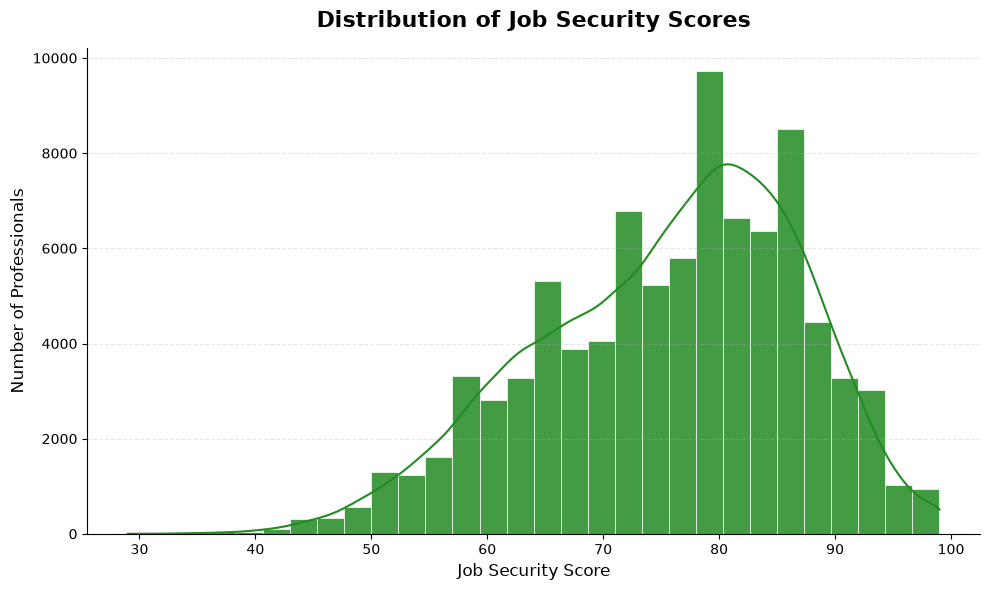

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="job_security_score",
    bins=30,
    kde=True,
    color="forestgreen",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Job Security Scores", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Job Security Score", fontsize=12)
ax.set_ylabel("Number of Professionals", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 2: Layoff Risk Distribution

**Business Objective:** Visualize layoff risk distribution to understand workforce risk patterns and support business decision-making.

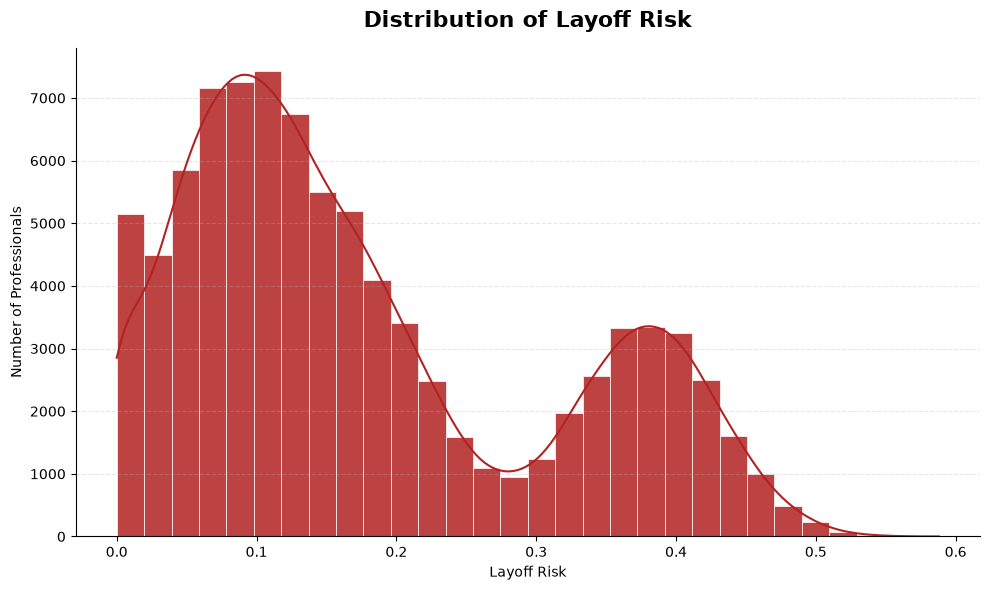

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="layoff_risk",
    bins=30,
    kde=True,
    color="firebrick",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Layoff Risk", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Layoff Risk")
ax.set_ylabel("Number of Professionals")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 3: Automation Risk Distribution

**Business Objective:** Visualize automation risk distribution to understand workforce risk patterns and support business decision-making.

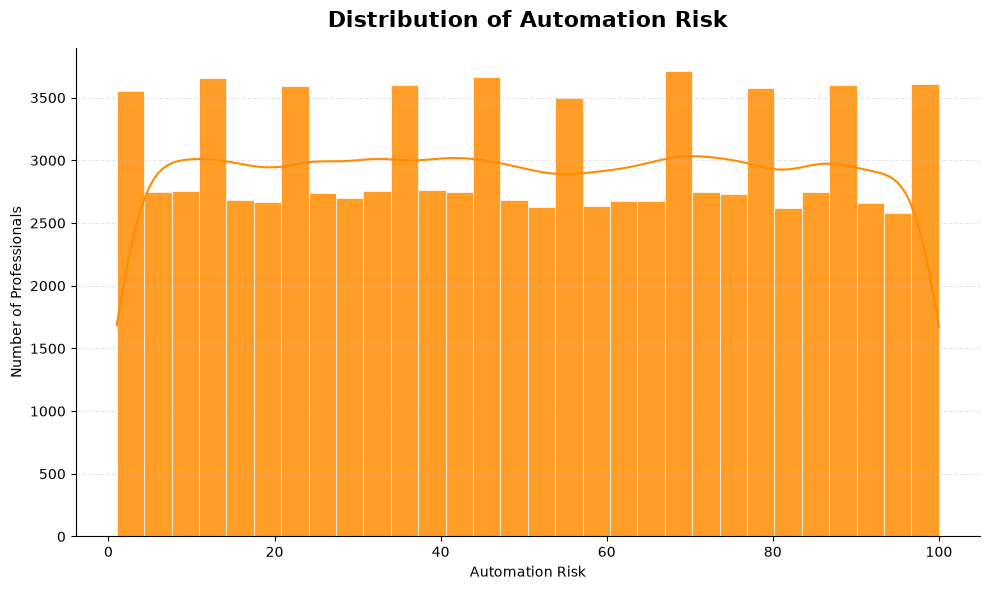

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="automation_risk",
    bins=30,
    kde=True,
    color="darkorange",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Automation Risk", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Automation Risk")
ax.set_ylabel("Number of Professionals")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 4: Job Security by Experience Level

**Business Objective:** Visualize job security by experience level to understand workforce risk patterns and support business decision-making.

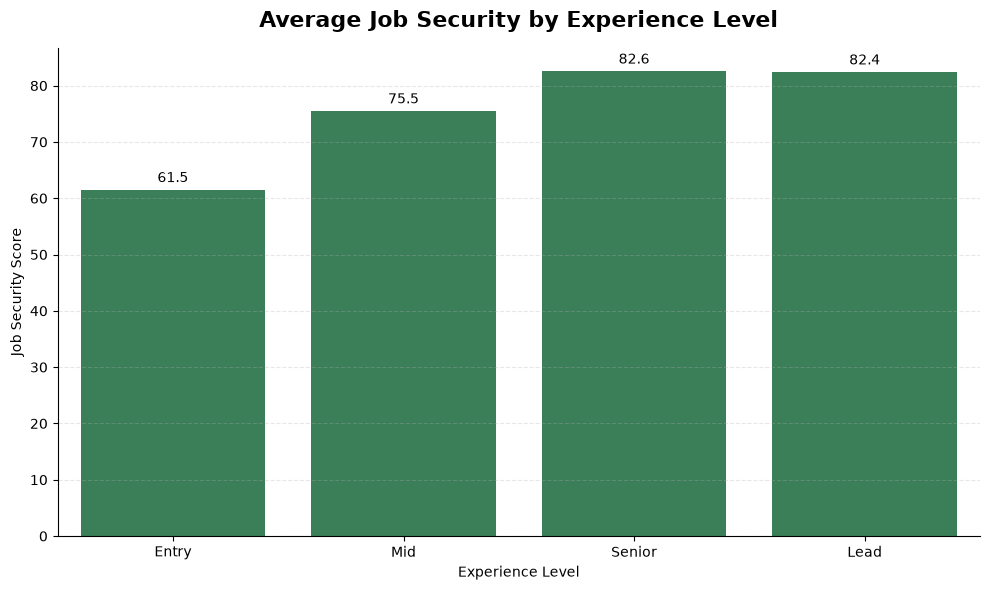

In [30]:
# Experience Level Order

experience_order = [
    "Entry",
    "Mid",
    "Senior",
    "Lead"
]

job_security_exp = (
    df.groupby("experience_level", observed=False)["job_security_score"]
    .mean()
    .reindex(experience_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=job_security_exp,
    x="experience_level",
    y="job_security_score",
    color="seagreen",
    ax=ax
)

if ax.containers:
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=10)

ax.set_title("Average Job Security by Experience Level", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Experience Level")
ax.set_ylabel("Job Security Score")
ax.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 5: Top 10 Countries by Job Security

**Business Objective:** Visualize top 10 countries by job security to understand workforce risk patterns and support business decision-making.

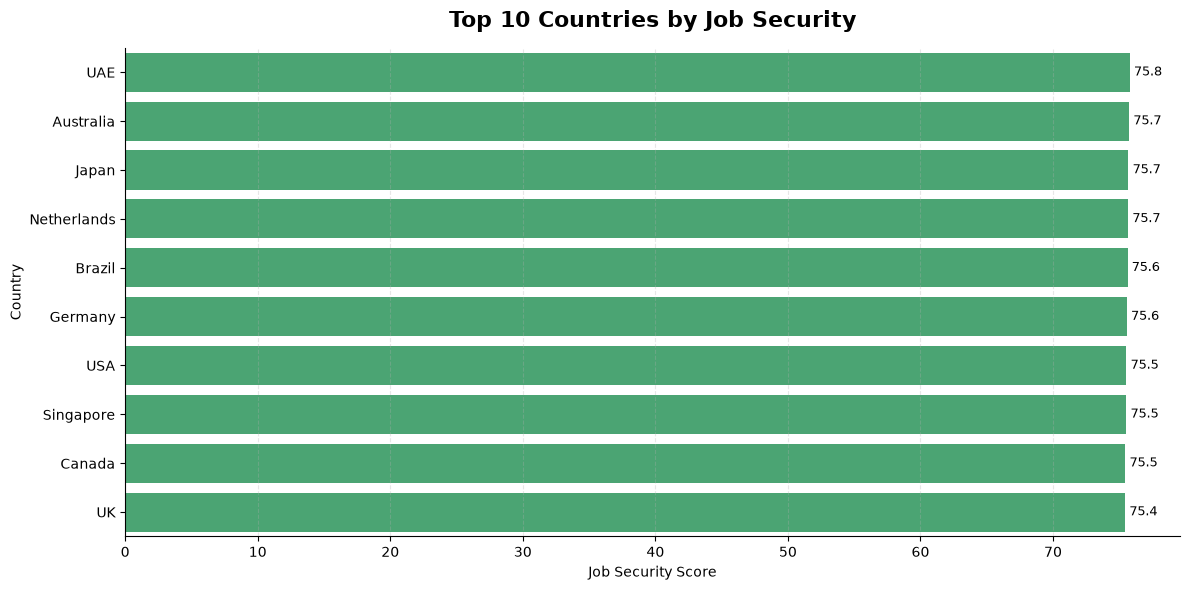

In [31]:
job_security_country = (
    df.groupby("country")["job_security_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=job_security_country,
    x="job_security_score",
    y="country",
    color="mediumseagreen",
    ax=ax
)

if ax.containers:
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)

ax.set_title("Top 10 Countries by Job Security", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Job Security Score")
ax.set_ylabel("Country")
ax.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 6: Top 10 Job Roles by Automation Risk

**Business Objective:** Visualize top 10 job roles by automation risk to understand workforce risk patterns and support business decision-making.

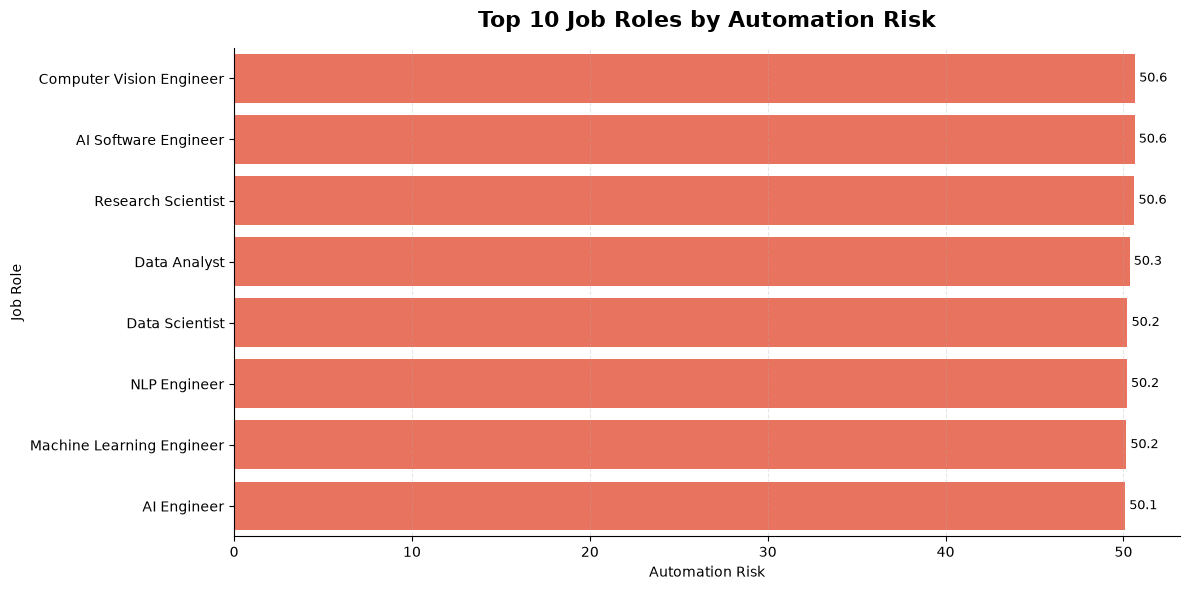

In [32]:
automation_role = (
    df.groupby("job_role")["automation_risk"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=automation_role,
    x="automation_risk",
    y="job_role",
    color="tomato",
    ax=ax
)

if ax.containers:
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)

ax.set_title("Top 10 Job Roles by Automation Risk", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Automation Risk")
ax.set_ylabel("Job Role")
ax.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 7: AI Adoption by Industry

**Business Objective:** Visualize ai adoption by industry to understand workforce risk patterns and support business decision-making.

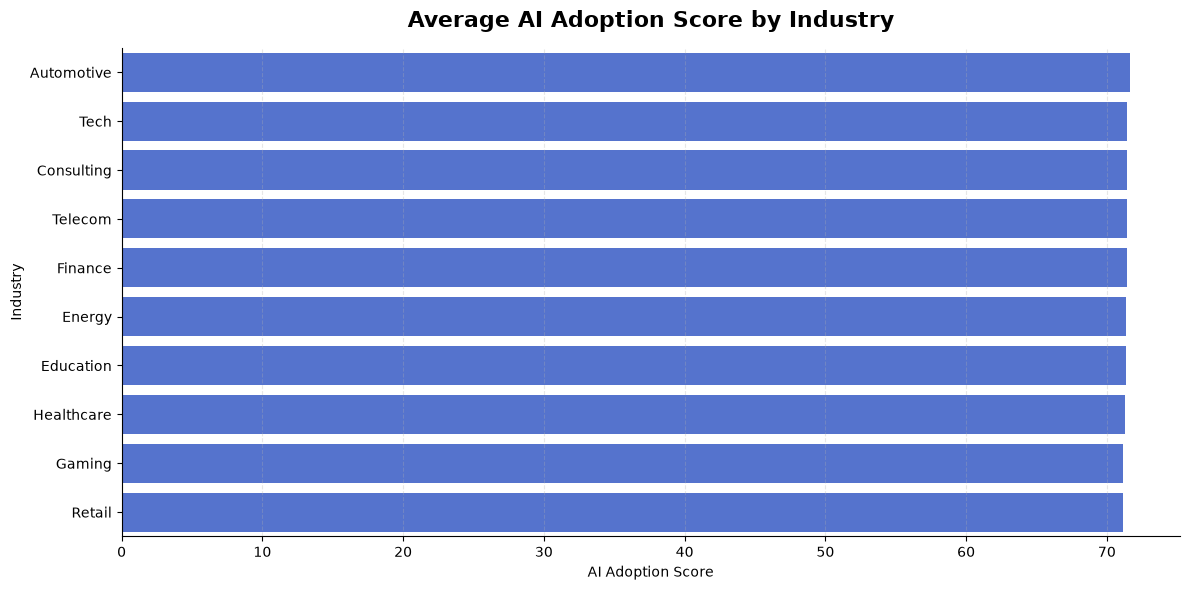

In [33]:
ai_adoption = (
    df.groupby("industry")["ai_adoption_score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=ai_adoption,
    x="ai_adoption_score",
    y="industry",
    color="royalblue",
    ax=ax
)

ax.set_title("Average AI Adoption Score by Industry", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("AI Adoption Score")
ax.set_ylabel("Industry")
ax.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

## Chart 8: Layoff Risk vs Job Security

**Business Objective:** Visualize layoff risk vs job security to understand workforce risk patterns and support business decision-making.

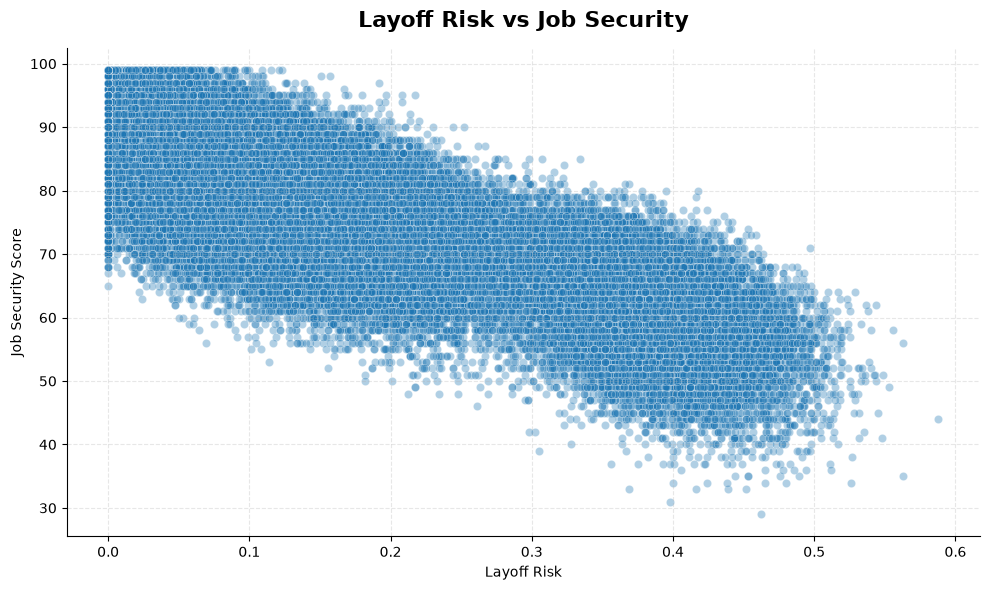

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="layoff_risk",
    y="job_security_score",
    alpha=0.35,
    s=35,
    ax=ax
)

ax.set_title("Layoff Risk vs Job Security", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Layoff Risk")
ax.set_ylabel("Job Security Score")
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

In [35]:
# Create Engineered Workforce Risk Features

df["workforce_stability_index"] = (
    (
        df["job_security_score"] +
        df["ai_adoption_score"] +
        (100 - df["layoff_risk"] * 100)
    ) / 3
).round(2)

df["automation_resilience_score"] = (
    (
        df["job_security_score"] +
        (100 - df["automation_risk"])
    ) / 2
).round(2)

df["risk_exposure_index"] = (
    (
        (df["layoff_risk"] * 100) +
        df["automation_risk"]
    ) / 2
).round(2)

df["ai_workforce_readiness_score"] = (
    (
        df["job_security_score"] +
        df["ai_adoption_score"] +
        df["skill_demand_score"]
    ) / 3
).round(2)

df["stability_risk_ratio"] = (
    df["job_security_score"] /
    (df["layoff_risk"] * 100 + 1)
).round(2)

## Chart 9: Workforce Stability Index Distribution

**Business Objective:** Visualize workforce stability index distribution to understand workforce risk patterns and support business decision-making.

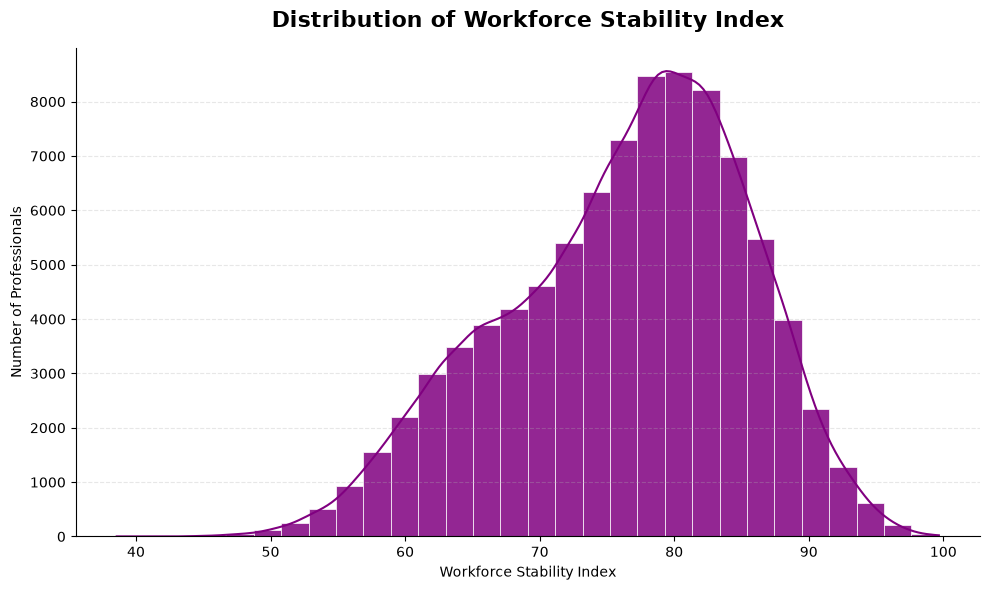

In [36]:
# Chart 9: Workforce Stability Index Distribution

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=df,
    x="workforce_stability_index",
    bins=30,
    kde=True,
    color="purple",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85,
    ax=ax
)

ax.set_title(
    "Distribution of Workforce Stability Index",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Workforce Stability Index")
ax.set_ylabel("Number of Professionals")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

## Chart 10: Workforce Risk Correlation Matrix

**Business Objective:** Visualize workforce risk correlation matrix to understand workforce risk patterns and support business decision-making.

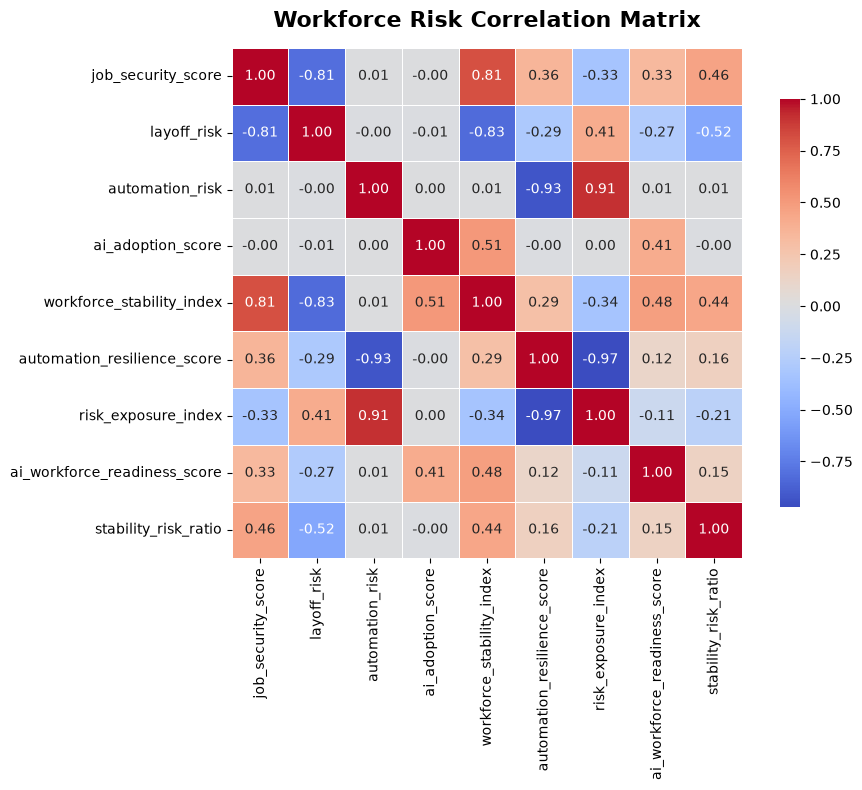

In [37]:
# Chart 10: Workforce Risk Correlation Matrix

risk_corr = (
    df[
        [
            "job_security_score",
            "layoff_risk",
            "automation_risk",
            "ai_adoption_score",
            "workforce_stability_index",
            "automation_resilience_score",
            "risk_exposure_index",
            "ai_workforce_readiness_score",
            "stability_risk_ratio"
        ]
    ]
    .corr()
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    risk_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Workforce Risk Correlation Matrix",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()